# 03_tstr_a1a2_v1 — Comparativa TSTR sobre A1/A2 (LSTM-VAE Baseline v2)
## LSTM-VAE: Real Only | Synthetic Only | Real + Synthetic

Evalua el impacto de los datos sinteticos del TimeGAN A1/A2 v2 sobre
la capacidad de deteccion de anomalias del detector LSTM-VAE.

**Protocolo de evaluacion:**
- Entrenamiento: datos de Normal_v1.xlsx (real) y/o sinteticos del GAN
- Evaluacion: SWaT_Dataset_Attack_v0.xlsx (contiene ataques reales)
- Val durante training: split 20% de Normal_v1 (mismo que baseline)
- Exclusion de ataques sigilosos indetectables (IDs 1, 2) siguiendo baseline

**Comparacion justa:**
- Arquitectura, hiperparametros y scaler identicos al baseline v2
- Protocolo de evaluacion identico: CONSEC_K=13, sweep 800 taus
- Val siempre es el mismo conjunto (20% Normal_v1) en los 3 escenarios


## 0. Imports

In [1]:
import json, joblib, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import warnings; warnings.filterwarnings("ignore")


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## 1. Rutas

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / "data").exists() else current_dir.parent

# Dataset A1/A2 (misma ruta que TimeGAN v2)
CLEAN_DIR    = PROJECT_ROOT / "data" / "clean" / "SWaT.A1 & A2_Dec 2015"
NORMAL_XLSX  = CLEAN_DIR / "SWaT_Dataset_Normal_v1.xlsx"
ATTACK_XLSX  = CLEAN_DIR / "SWaT_Dataset_Attack_v0.xlsx"

# Detector LSTM-VAE A1/A2 baseline v2
DETECTOR_DIR = PROJECT_ROOT / "models" / "detectors" / "lstm_vae_swat_a1a2_baseline_v2"
OPTUNA_CFG   = (PROJECT_ROOT / "models" / "detectors"
                / "lstm_vae_swat_a1a2_optuna_v1" / "optuna_best_config.json")

# Sinteticos del TimeGAN A1/A2 v2 (mismo TIMEGAN_DIR del GAN)
SYNTH_DIR    = PROJECT_ROOT / "models" / "timegan" / "lstm_vae_a1a2_baseline_v2"

# Directorio de salida de este TSTR
TSTR_DIR     = PROJECT_ROOT / "models" / "detectors" / "lstm_vae_tstr_a1a2_v1"
TSTR_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT.resolve())
print("Normal XLSX  :", NORMAL_XLSX.exists())
print("Attack XLSX  :", ATTACK_XLSX.exists())
print("Detector dir :", DETECTOR_DIR.exists())
print("Optuna cfg   :", OPTUNA_CFG.exists())
print("Synth dir    :", SYNTH_DIR.exists())
print("TSTR dir     :", TSTR_DIR)


PROJECT_ROOT : C:\Users\j.manriquec\ics-synthetic-data-augmentation
Normal XLSX  : True
Attack XLSX  : True
Detector dir : True
Optuna cfg   : True
Synth dir    : True
TSTR dir     : c:\Users\j.manriquec\ics-synthetic-data-augmentation\models\detectors\lstm_vae_tstr_a1a2_v1


## 2. Hiperparametros (identicos al baseline v2)

Se cargan desde `optuna_best_config.json` y del `DETECTOR_DIR` para
garantizar que la arquitectura y el scaler son exactamente los mismos
que el detector baseline. Comparacion justa.

In [25]:
with open(OPTUNA_CFG) as f:
    optuna_cfg = json.load(f)

CONTINUOUS_COLS = optuna_cfg["continuous_cols"]
DISCRETE_COLS   = optuna_cfg["discrete_cols"]
ALL_SENSOR_COLS = CONTINUOUS_COLS + DISCRETE_COLS
bp              = optuna_cfg["best_params"]

# Arquitectura -- identica a baseline v2
WINDOW_SIZE = int(optuna_cfg["window_size"])   # 60
STRIDE      = 5                                # mismo que baseline
HIDDEN_SIZE = int(bp.get("hidden_size", 256))
NUM_LAYERS  = int(bp["num_layers"])
LATENT_DIM  = int(bp.get("latent_dim", 128))
DISC_HIDDEN = int(optuna_cfg.get("disc_hidden", 64))
BETA        = float(bp["beta"])
ALPHA       = float(bp["alpha"])
DROPOUT     = float(bp["dropout"])
LR          = float(bp["lr"])
BATCH_SIZE  = int(bp["batch_size"])

# Pipeline
CLIP_VAL    = float(optuna_cfg.get("clip_val", 5.0))
WARMUP_SEC  = int(optuna_cfg.get("warmup_sec", 1800))
MAX_EPOCHS  = 150
PATIENCE    = 20

# Protocolo de evaluacion
EXCLUDED_IDS = []    # Ataques sigilosos indetectables (mismos que baseline)
CONSEC_K     = 13        # Filtro de ventanas consecutivas (mismo que baseline)

print(f"Arquitectura : hidden={HIDDEN_SIZE} | layers={NUM_LAYERS} | latent={LATENT_DIM}")
print(f"Entrenamiento: beta={BETA:.4f} | alpha={ALPHA:.4f} | lr={LR:.2e} | batch={BATCH_SIZE}")
print(f"Pipeline     : window={WINDOW_SIZE} | stride={STRIDE} | clip={CLIP_VAL} | warmup={WARMUP_SEC}s")
print(f"Evaluacion   : excl={EXCLUDED_IDS} | k={CONSEC_K}")
print(f"Columnas     : {len(CONTINUOUS_COLS)} continuas | {len(DISCRETE_COLS)} discretas")


Arquitectura : hidden=128 | layers=1 | latent=96
Entrenamiento: beta=0.0673 | alpha=0.8775 | lr=1.60e-04 | batch=512
Pipeline     : window=60 | stride=5 | clip=5.0 | warmup=1800s
Evaluacion   : excl=[] | k=13
Columnas     : 25 continuas | 26 discretas


## 3. Carga del dataset Normal v1 y split 60/20/20

Sesion unica de operacion normal. Se aplica warmup y split temporal estricto.
El val se usa en early stopping durante el entrenamiento de los 3 escenarios.
Los datos de ataque se cargan por separado solo para evaluacion.

In [5]:
def load_swat_xlsx(path, normal_only=True):
    """Carga XLSX de SWaT A1/A2.
    A1/A2 tiene header en fila 1 y columna Timestamp.
    El label es la columna " Normal/Attack" (con espacio inicial).
    """
    df = pd.read_excel(path, header=1, engine="openpyxl")
    # Limpiar nombres de columnas
    df.columns = df.columns.str.strip()
    # Columna de label
    label_col = [c for c in df.columns if "Normal" in c or "Attack" in c
                 and c not in ALL_SENSOR_COLS]
    if label_col:
        df["attack_label"] = (df[label_col[0]].str.strip() == "Attack").astype(int)
    else:
        df["attack_label"] = 0  # Normal_v1 no tiene columna de ataque
    # Timestamp
    ts_col = [c for c in df.columns if "Timestamp" in c or "timestamp" in c]
    if ts_col:
        df["t_stamp"] = pd.to_datetime(df[ts_col[0]], errors="coerce")
    else:
        df["t_stamp"] = pd.RangeIndex(len(df))
    df = df.sort_values("t_stamp").reset_index(drop=True)
    # Limpiar tipos mixtos
    for col in ALL_SENSOR_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    if normal_only:
        df = df[df["attack_label"] == 0].copy().reset_index(drop=True)
    return df

print("Cargando Normal_v1.xlsx...")
df_normal_raw = load_swat_xlsx(NORMAL_XLSX, normal_only=True)
# Aplicar warmup
t0 = df_normal_raw["t_stamp"].min()
df_normal = df_normal_raw[
    df_normal_raw["t_stamp"] >= t0 + pd.Timedelta(seconds=WARMUP_SEC)
].copy().reset_index(drop=True)
print(f"Total filas normales post-warmup: {len(df_normal):,}")
print(f"Periodo: {df_normal["t_stamp"].min()} -> {df_normal["t_stamp"].max()}")

# Imputar NaN
modes_normal = df_normal[ALL_SENSOR_COLS].mode().iloc[0]
df_normal[ALL_SENSOR_COLS] = df_normal[ALL_SENSOR_COLS].fillna(modes_normal)
nan_left = df_normal[ALL_SENSOR_COLS].isna().sum().sum()
print(f"NaN tras imputacion: {nan_left}")

# Split temporal 60/20/20
n  = len(df_normal)
t1 = int(n * 0.60)
t2 = int(n * 0.80)
df_train = df_normal.iloc[:t1].copy().reset_index(drop=True)
df_val   = df_normal.iloc[t1:t2].copy().reset_index(drop=True)
df_test  = df_normal.iloc[t2:].copy().reset_index(drop=True)
print(f"Split: train={len(df_train):,} | val={len(df_val):,} | test={len(df_test):,}")


Cargando Normal_v1.xlsx...
Total filas normales post-warmup: 493,200
Periodo: 2015-12-22 17:00:00 -> 2015-12-28 09:59:59
NaN tras imputacion: 0
Split: train=295,920 | val=98,640 | test=98,640


## 4. Escalado (scaler del detector baseline v2)

Se carga el `scaler_cont.pkl` y `disc_max_dict.pkl` del directorio del detector.
Esto garantiza que los datos reales, sinteticos y de evaluacion estan en
exactamente el mismo espacio que el detector fue entrenado.

In [6]:
# Cargar scaler y disc_max del detector (ya fiteados en baseline v2)
scaler_cont  = joblib.load(DETECTOR_DIR / "scaler_cont.pkl")
disc_max_raw = joblib.load(DETECTOR_DIR / "disc_max_dict.pkl")
disc_max     = pd.Series(disc_max_raw).replace(0, 1)

def scale_df(df):
    """Escala un DataFrame usando el scaler del detector.
    Aplica StandardScaler a continuas y normalizacion [0,1] a discretas.
    """
    df = df.copy()
    df[CONTINUOUS_COLS] = np.clip(
        scaler_cont.transform(df[CONTINUOUS_COLS].values), -CLIP_VAL, CLIP_VAL
    )
    df[DISCRETE_COLS] = (df[DISCRETE_COLS] / disc_max).clip(0, 1)
    return df

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)
df_test_sc  = scale_df(df_test)

print(f"Scaler cargado de: {DETECTOR_DIR / "scaler_cont.pkl"}")
print(f"Rango train escalado: [{df_train_sc[CONTINUOUS_COLS].values.min():.2f}, {df_train_sc[CONTINUOUS_COLS].values.max():.2f}]")
print(f"(esperado: [-{CLIP_VAL}, {CLIP_VAL}])")


Scaler cargado de: c:\Users\j.manriquec\ics-synthetic-data-augmentation\models\detectors\lstm_vae_swat_a1a2_baseline_v2\scaler_cont.pkl
Rango train escalado: [-5.00, 5.00]
(esperado: [-5.0, 5.0])


## 5. Ventanas reales y sinteticos

Construccion de ventanas deslizantes sobre los datos escalados.
Los sinteticos se cargan directamente del directorio del TimeGAN v2
en formato (N, T, C), ya escalados con el mismo scaler.

In [7]:
def create_windows(arr, ws, stride):
    """Ventanas deslizantes. Retorna (N, ws, C) -- formato LSTM."""
    wins = [arr[i:i+ws] for i in range(0, len(arr)-ws+1, stride)]
    return np.array(wins, dtype=np.float32) if wins \
           else np.empty((0, ws, arr.shape[1]), dtype=np.float32)

def summarize_discrete_windows(disc_windows, dcols):
    """Summary stats por ventana para variables discretas.
    Produce: mode, transitions, nunique, dominance por columna.
    """
    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(dcols):
            v = w[:, j]; s = pd.Series(v)
            feats[f"{col}__mode"]        = s.mode().iloc[0] if len(s.mode())>0 else 0.0
            feats[f"{col}__transitions"] = float(np.sum(v[1:] != v[:-1]))
            feats[f"{col}__nunique"]     = float(len(np.unique(v)))
            feats[f"{col}__dominance"]   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

def build_windows_pair(df_sc, ws, stride):
    """Construye ventanas continuas y summary discreto desde un DataFrame escalado."""
    wc  = create_windows(df_sc[CONTINUOUS_COLS].values.astype(np.float32), ws, stride)
    wd  = create_windows(df_sc[DISCRETE_COLS].values.astype(np.float32),   ws, stride)
    wds = summarize_discrete_windows(wd, DISCRETE_COLS).values.astype(np.float32)
    return wc, wds

# Ventanas de entrenamiento reales
X_tr_c, X_tr_d = build_windows_pair(df_train_sc, WINDOW_SIZE, STRIDE)
X_va_c, X_va_d = build_windows_pair(df_val_sc,   WINDOW_SIZE, STRIDE)
X_te_c, X_te_d = build_windows_pair(df_test_sc,  WINDOW_SIZE, STRIDE)

print(f"Train: {X_tr_c.shape}  | Val: {X_va_c.shape}  | Test: {X_te_c.shape}")
print(f"Disc summary dim: {X_tr_d.shape[1]}")

# Sinteticos del TimeGAN A1/A2 v2
X_sy_c = np.load(SYNTH_DIR / "X_synth_cont.npy").astype(np.float32)
X_sy_d = np.load(SYNTH_DIR / "X_synth_disc.npy").astype(np.float32)
print(f"\nSinteticos cont : {X_sy_c.shape}")
print(f"Sinteticos disc : {X_sy_d.shape}")
assert X_tr_c.shape[1:] == X_sy_c.shape[1:], f"Shape mismatch: real={X_tr_c.shape[1:]} synth={X_sy_c.shape[1:]}"
assert X_tr_d.shape[1]  == X_sy_d.shape[1],  f"Disc dim mismatch: real={X_tr_d.shape[1]} synth={X_sy_d.shape[1]}"
print("Verificacion dimensiones: OK")
print(f"\nEstadisticas espacio escalado (continuas):")
print(f"  Real  media:{X_tr_c.mean():.4f}  std:{X_tr_c.std():.4f}")
print(f"  Synth media:{X_sy_c.mean():.4f}  std:{X_sy_c.std():.4f}")


Train: (59173, 60, 25)  | Val: (19717, 60, 25)  | Test: (19717, 60, 25)
Disc summary dim: 104

Sinteticos cont : (29587, 60, 25)
Sinteticos disc : (29587, 104)
Verificacion dimensiones: OK

Estadisticas espacio escalado (continuas):
  Real  media:-0.0009  std:0.9785
  Synth media:-0.0015  std:0.9701


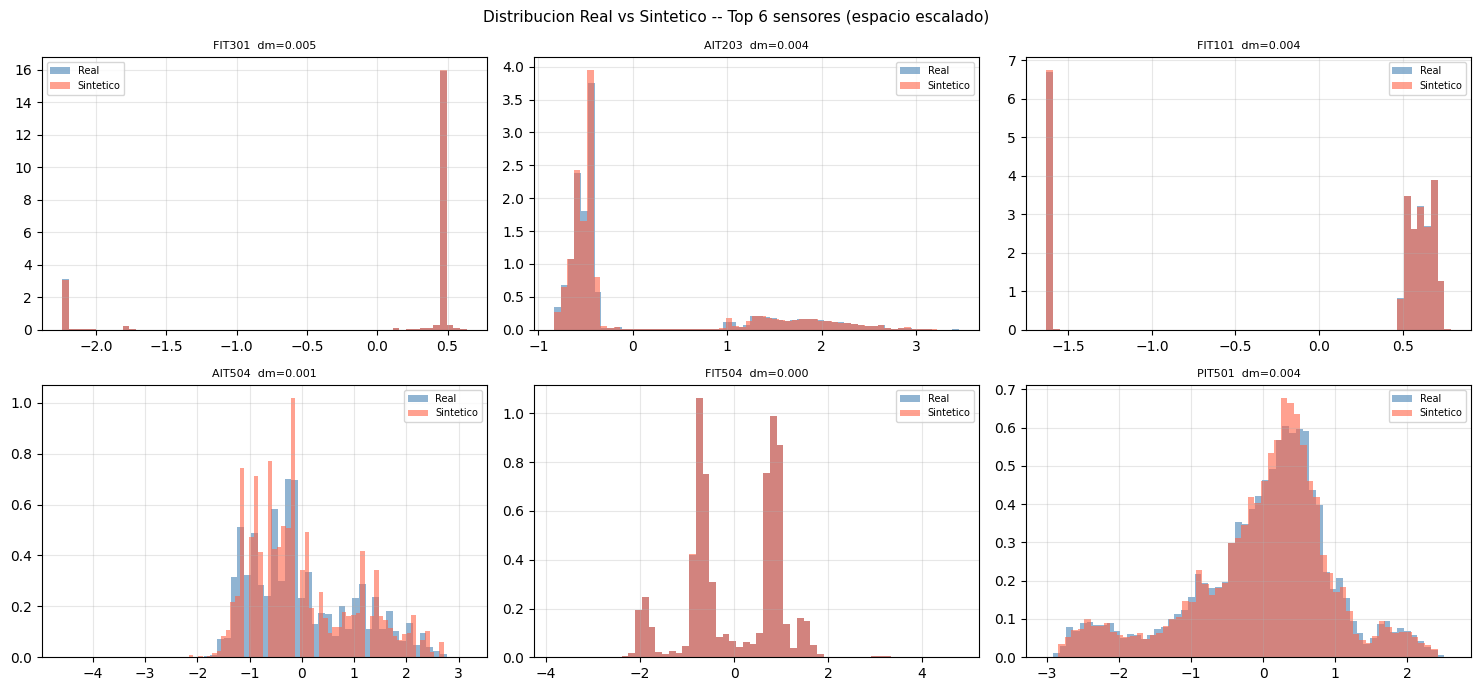

In [8]:
# Comparacion visual de distribuciones (top 6 sensores por varianza)
var_r  = X_tr_c.reshape(-1, X_tr_c.shape[2]).var(axis=0)
top6   = np.argsort(var_r)[-6:][::-1]
rf     = X_tr_c.reshape(-1, X_tr_c.shape[2])
sf     = X_sy_c.reshape(-1, X_sy_c.shape[2])
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, idx in zip(axes.flat, top6):
    nm = CONTINUOUS_COLS[idx]
    ax.hist(rf[:,idx], bins=60, alpha=0.6, density=True, color="steelblue", label="Real")
    ax.hist(sf[:,idx], bins=60, alpha=0.6, density=True, color="tomato",    label="Sintetico")
    dm = abs(rf[:,idx].mean() - sf[:,idx].mean())
    ax.set_title(f"{nm}  dm={dm:.3f}", fontsize=8)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle("Distribucion Real vs Sintetico -- Top 6 sensores (espacio escalado)", fontsize=11)
plt.tight_layout()
plt.savefig(str(TSTR_DIR / "dist_real_vs_synth.png"), dpi=120, bbox_inches="tight")
plt.show()


## 6. Arquitectura LSTM-VAE (identica al baseline v2)

In [9]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, latent_dim, dropout):
        super().__init__()
        self.lstm      = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.drop      = nn.Dropout(dropout)
        self.fc_mu     = nn.Linear(hidden_size, latent_dim)
        self.fc_logvar = nn.Linear(hidden_size, latent_dim)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h_last = self.drop(h[-1])
        return self.fc_mu(h_last), self.fc_logvar(h_last)

class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_size, num_layers, output_size, seq_len, dropout):
        super().__init__()
        self.seq_len    = seq_len
        self.num_layers = num_layers
        self.fc_h0      = nn.Linear(latent_dim, hidden_size)
        self.lstm       = nn.LSTM(latent_dim, hidden_size, num_layers, batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0.0)
        self.drop       = nn.Dropout(dropout)
        self.fc_out     = nn.Linear(hidden_size, output_size)
    def forward(self, z):
        h0 = torch.tanh(self.fc_h0(z)).unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(z.unsqueeze(1).repeat(1, self.seq_len, 1), (h0, c0))
        return self.fc_out(self.drop(out))

class HybridLSTMVAE(nn.Module):
    def __init__(self, cont_size, seq_len, disc_dim,
                 hidden_size=128, num_layers=2, latent_dim=64, disc_hidden=64, dropout=0.2):
        super().__init__()
        self.encoder_cont = LSTMEncoder(cont_size, hidden_size, num_layers, latent_dim, dropout)
        self.decoder_cont = LSTMDecoder(latent_dim, hidden_size, num_layers, cont_size, seq_len, dropout)
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden, disc_hidden // 2), nn.ReLU())
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden // 2, disc_hidden), nn.ReLU(),
            nn.Linear(disc_hidden, disc_dim))
    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu
    def forward(self, xc, xd):
        mu, logvar = self.encoder_cont(xc)
        z = self.reparameterize(mu, logvar)
        return self.decoder_cont(z), self.decoder_disc(self.encoder_disc(xd)), mu, logvar

n_params = sum(p.numel() for p in HybridLSTMVAE(
    cont_size=X_tr_c.shape[2], seq_len=WINDOW_SIZE,
    disc_dim=X_tr_d.shape[1],  hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,     latent_dim=LATENT_DIM,
    disc_hidden=DISC_HIDDEN,   dropout=DROPOUT
).parameters())
print(f"Parametros totales: {n_params:,}")


Parametros totales: 253,153


## 7. Funciones de entrenamiento y evaluacion

In [10]:
def elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, alpha, beta):
    mse_c = nn.functional.mse_loss(xc_hat, xc)
    mse_d = nn.functional.mse_loss(xd_hat, xd)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return alpha*(mse_c + beta*kl) + (1-alpha)*mse_d, mse_c, mse_d, kl

def build_model():
    return HybridLSTMVAE(
        cont_size=X_tr_c.shape[2], seq_len=WINDOW_SIZE,
        disc_dim=X_tr_d.shape[1],  hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,     latent_dim=LATENT_DIM,
        disc_hidden=DISC_HIDDEN,   dropout=DROPOUT
    ).to(device)

def train_model(Xc_train, Xd_train, label):
    """Val siempre = X_va_c / X_va_d (20% de Normal_v1) para comparacion justa."""
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    model = build_model()
    tr_loader = DataLoader(
        TensorDataset(torch.tensor(Xc_train, dtype=torch.float32),
                      torch.tensor(Xd_train, dtype=torch.float32)),
        batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    va_loader = DataLoader(
        TensorDataset(torch.tensor(X_va_c, dtype=torch.float32),
                      torch.tensor(X_va_d, dtype=torch.float32)),
        batch_size=BATCH_SIZE, shuffle=False)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,"min",factor=0.5,patience=10,min_lr=1e-6)
    best_val = float("inf"); best_wts = None; no_imp = 0; best_ep = 1
    tr_hist = []; va_hist = []
    print(f"\n[{label}] {len(Xc_train):,} train | {len(X_va_c):,} val | batch={BATCH_SIZE}")
    for ep in range(1, MAX_EPOCHS+1):
        model.train()
        tl = 0.0
        for xc_b, xd_b in tr_loader:
            xc_b = xc_b.to(device); xd_b = xd_b.to(device)
            opt.zero_grad()
            xc_h, xd_h, mu, lv = model(xc_b, xd_b)
            loss = elbo_loss(xc_b, xc_h, xd_b, xd_h, mu, lv, ALPHA, BETA)[0]
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            tl += loss.item()
        tl /= len(tr_loader)
        model.eval()
        vl = 0.0
        with torch.no_grad():
            for xc_b, xd_b in va_loader:
                xc_b = xc_b.to(device); xd_b = xd_b.to(device)
                xc_h, xd_h, mu, lv = model(xc_b, xd_b)
                vl += elbo_loss(xc_b, xc_h, xd_b, xd_h, mu, lv, ALPHA, BETA)[0].item()
        vl /= len(va_loader)
        sched.step(vl)
        tr_hist.append(tl); va_hist.append(vl)
        if vl < best_val - 1e-6:
            best_val = vl; best_ep = ep; no_imp = 0
            best_wts = {kk: vv.clone() for kk, vv in model.state_dict().items()}
        else:
            no_imp += 1
        if ep % 20 == 0:
            print(f"  Ep {ep:4d} | Train:{tl:.5f} | Val:{vl:.5f} | Best:{best_val:.5f}(ep{best_ep})")
        if no_imp >= PATIENCE:
            print(f"  Early stop ep{ep}."); break
    model.load_state_dict(best_wts); model.eval()
    print(f"  Mejor val:{best_val:.5f} ep{best_ep}")
    return model, tr_hist, va_hist, best_ep, best_val

def recon_scores(model, Xc, Xd, alpha, bs=256):
    ldr = DataLoader(TensorDataset(torch.tensor(Xc, dtype=torch.float32),
                                   torch.tensor(Xd, dtype=torch.float32)),
                     batch_size=bs, shuffle=False)
    ec_l = []; ed_l = []
    model.eval()
    with torch.no_grad():
        for xc_b, xd_b in ldr:
            xc_b = xc_b.to(device); xd_b = xd_b.to(device)
            xc_h, xd_h, mu, _ = model(xc_b, xd_b)
            ec_l.extend(torch.mean((xc_h-xc_b)**2, dim=(1,2)).cpu().numpy())
            ed_l.extend(torch.mean((xd_h-xd_b)**2, dim=1).cpu().numpy())
    return ALPHA*np.array(ec_l) + (1-ALPHA)*np.array(ed_l)

def consec_filter(scores_arr, tau, k):
    raw = (scores_arr > tau).astype(int)
    if k <= 1: return raw
    out = np.zeros_like(raw)
    for ii in range(k-1, len(raw)):
        out[ii] = int(raw[ii-k+1:ii+1].all())
    return out

def evaluate_model(model, Xev_c, Xev_d, y_ev, df_ev, excl_ids, k_consec):
    sc = recon_scores(model, Xev_c, Xev_d, ALPHA)
    assert len(sc) == len(y_ev)
    mn = sc[y_ev==0].mean(); ma = sc[y_ev==1].mean() if (y_ev==1).any() else 0.0
    auc_ref = roc_auc_score(y_ev, sc)
    # Excluir ataques sigilosos
    keep = ~((df_ev["y"].values==1) & np.isin(df_ev["attack_id"].values, excl_ids))
    sc_f = sc[keep]; y_f = y_ev[keep]
    # Sweep tau
    taus = np.percentile(sc_f, np.linspace(0.5, 99.5, 800))
    bf1 = -1.0; btau = float(taus[0])
    for tau in taus:
        pr = consec_filter(sc_f, tau, k_consec)
        tp_ = int(((pr==1)&(y_f==1)).sum()); fp_ = int(((pr==1)&(y_f==0)).sum())
        fn_ = int(((pr==0)&(y_f==1)).sum())
        pp = tp_/(tp_+fp_+1e-10); rr = tp_/(tp_+fn_+1e-10)
        ff = 2*pp*rr/(pp+rr+1e-10)
        if ff > bf1: bf1 = ff; btau = float(tau)
    pr_f = consec_filter(sc_f, btau, k_consec)
    tp = int(((pr_f==1)&(y_f==1)).sum())
    fp = int(((pr_f==1)&(y_f==0)).sum())
    fn = int(((pr_f==0)&(y_f==1)).sum())
    tn = int(((pr_f==0)&(y_f==0)).sum())
    prec = tp/(tp+fp+1e-10); rec = tp/(tp+fn+1e-10)
    f1   = 2*prec*rec/(prec+rec+1e-10)
    fpr  = fp/(fp+tn+1e-10)
    return {
        "tau": btau,
        "roc_auc": float(roc_auc_score(y_f, sc_f)),
        "roc_auc_ref": float(auc_ref),
        "pr_auc": float(average_precision_score(y_f, sc_f)),
        "f1": float(f1), "recall": float(rec),
        "precision": float(prec), "fpr": float(fpr),
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "ratio": float(ma/mn) if mn > 0 else 0.0,
        "sc_all": sc, "sc_filt": sc_f, "y_filt": y_f,
    }

print("Funciones definidas: elbo_loss, build_model, train_model, "
      "recon_scores, consec_filter, evaluate_model")


Funciones definidas: elbo_loss, build_model, train_model, recon_scores, consec_filter, evaluate_model


## 8. Carga del dataset de ataques (evaluacion)

Se carga `SWaT_Dataset_Attack_v0.xlsx` con todas las sesiones de ataque.
El label `Normal/Attack` se convierte a 0/1. Se construyen ventanas
con los mismos parametros que el training. Los metadatos del ataque
(ID, nombre) se extraen para el analisis por tipo de ataque.

In [11]:
print("Cargando Attack_v0.xlsx (datos de evaluacion)...")
df_attack_raw = pd.read_excel(ATTACK_XLSX, header=1, engine="openpyxl")
df_attack_raw.columns = df_attack_raw.columns.str.strip()

# Identificar columna de label
label_col = [c for c in df_attack_raw.columns
             if ("Normal" in c or "Attack" in c) and c not in ALL_SENSOR_COLS]
print(f"Label column found: {label_col}")
lc = label_col[0] if label_col else None

if lc:
    df_attack_raw["attack_label"] = (df_attack_raw[lc].astype(str).str.strip() == "Attack").astype(int)
else:
    raise ValueError("No se encontro columna de label en Attack_v0.xlsx")

# Timestamp
ts_col = [c for c in df_attack_raw.columns if "Timestamp" in c or "timestamp" in c]
if ts_col:
    df_attack_raw["t_stamp"] = pd.to_datetime(df_attack_raw[ts_col[0]], errors="coerce")
df_attack_raw = df_attack_raw.sort_values("t_stamp").reset_index(drop=True)

# Limpiar tipos
for col in ALL_SENSOR_COLS:
    if col in df_attack_raw.columns:
        df_attack_raw[col] = pd.to_numeric(df_attack_raw[col], errors="coerce")
df_attack_raw[ALL_SENSOR_COLS] = df_attack_raw[ALL_SENSOR_COLS].fillna(modes_normal)

# En A1/A2, los ataques son numerados pero la columna exacta puede variar.
# Se intenta inferir el attack_id como numero de episodio de ataque.
atk_arr   = df_attack_raw["attack_label"].values
aid_arr   = np.zeros(len(df_attack_raw), dtype=float)
aname_arr = np.full(len(df_attack_raw), "normal", dtype=object)
current_id = 0; in_attack = False
for i in range(len(atk_arr)):
    if atk_arr[i] == 1 and not in_attack:
        current_id += 1; in_attack = True
    elif atk_arr[i] == 0:
        in_attack = False
    if atk_arr[i] == 1:
        aid_arr[i]   = float(current_id)
        aname_arr[i] = f"Attack_{current_id:02d}"

print(f"Total filas attack dataset: {len(df_attack_raw):,}")
print(f"Filas normales: {(atk_arr==0).sum():,}  | Filas ataque: {(atk_arr==1).sum():,}")
print(f"Episodios de ataque identificados: {int(current_id)}")

# Escalar
df_eval_sc = df_attack_raw[ALL_SENSOR_COLS].copy()
df_eval_cont = np.clip(scaler_cont.transform(
    df_eval_sc[CONTINUOUS_COLS].values), -CLIP_VAL, CLIP_VAL
).astype(np.float32)
df_eval_disc = (df_eval_sc[DISCRETE_COLS] / disc_max).clip(0, 1).values.astype(np.float32)

# Construir ventanas
wins_c, wins_d, meta_rows = [], [], []
for s in range(0, len(df_eval_cont) - WINDOW_SIZE + 1, STRIDE):
    wins_c.append(df_eval_cont[s:s+WINDOW_SIZE])
    wins_d.append(df_eval_disc[s:s+WINDOW_SIZE])
    seg_labs = atk_arr[s:s+WINDOW_SIZE]
    seg_aids = aid_arr[s:s+WINDOW_SIZE]
    seg_anms = aname_arr[s:s+WINDOW_SIZE]
    atk_ids  = seg_aids[seg_labs==1]
    atk_nms  = seg_anms[seg_labs==1]
    if len(atk_ids) > 0:
        uid, cnt = np.unique(atk_ids, return_counts=True); aid_mode = uid[cnt.argmax()]
        unm, cnm = np.unique(atk_nms, return_counts=True); anm_mode = unm[cnm.argmax()]
    else:
        aid_mode, anm_mode = 0, "normal"
    meta_rows.append({"y": int(np.any(seg_labs==1)),
                      "attack_id": aid_mode, "attack_name": str(anm_mode),
                      "attack_frac": float(np.mean(seg_labs==1))})

X_eval_c = np.array(wins_c, dtype=np.float32)
X_eval_d = summarize_discrete_windows(np.array(wins_d, dtype=np.float32), DISCRETE_COLS).values.astype(np.float32)
df_wins  = pd.DataFrame(meta_rows)
y_all    = df_wins["y"].values

print(f"\nVentanas eval (Attack): {len(df_wins):,}")
print(f"  Normal (y=0): {(df_wins["y"]==0).sum():,}")
print(f"  Ataque (y=1): {(df_wins["y"]==1).sum():,}  ({100*df_wins["y"].mean():.1f}%)")
print(f"  Tipos ataque: {df_wins[df_wins["y"]==1]["attack_id"].nunique()}")
assert len(X_eval_c) == len(y_all) == len(df_wins), "Mismatch eval lengths!"
print(f"X_eval_c: {X_eval_c.shape} | y_all: {len(y_all)} -- OK")


Cargando Attack_v0.xlsx (datos de evaluacion)...
Label column found: ['Normal/Attack']
Total filas attack dataset: 449,919
Filas normales: 395,335  | Filas ataque: 54,584
Episodios de ataque identificados: 35

Ventanas eval (Attack): 89,972
  Normal (y=0): 78,648
  Ataque (y=1): 11,324  (12.6%)
  Tipos ataque: 35
X_eval_c: (89972, 60, 25) | y_all: 89972 -- OK


## 9. Escenario 1 -- real_only

In [12]:
m_real, h_tr_r, h_va_r, ep_r, val_r = train_model(X_tr_c, X_tr_d, "real_only")
torch.save(m_real.state_dict(), TSTR_DIR / "model_real_only.pt")
print("Guardado: model_real_only.pt")



[real_only] 59,173 train | 19,717 val | batch=512
  Ep   20 | Train:0.13255 | Val:0.18906 | Best:0.18906(ep20)
  Ep   40 | Train:0.11658 | Val:0.17944 | Best:0.17804(ep39)
  Ep   60 | Train:0.10589 | Val:0.16994 | Best:0.16638(ep56)
  Ep   80 | Train:0.10138 | Val:0.16470 | Best:0.16374(ep64)
  Ep  100 | Train:0.09879 | Val:0.16147 | Best:0.16074(ep96)
  Ep  120 | Train:0.09657 | Val:0.15837 | Best:0.15730(ep116)
  Ep  140 | Train:0.09462 | Val:0.15627 | Best:0.15595(ep130)
  Mejor val:0.15528 ep147
Guardado: model_real_only.pt


## 10. Escenario 2 -- synthetic_only

In [13]:
m_synth, h_tr_s, h_va_s, ep_s, val_s = train_model(X_sy_c, X_sy_d, "synthetic_only")
torch.save(m_synth.state_dict(), TSTR_DIR / "model_synthetic_only.pt")
print("Guardado: model_synthetic_only.pt")



[synthetic_only] 29,587 train | 19,717 val | batch=512
  Ep   20 | Train:0.38295 | Val:0.85113 | Best:0.85027(ep19)
  Ep   40 | Train:0.34463 | Val:0.81412 | Best:0.81329(ep38)
  Ep   60 | Train:0.32840 | Val:0.80572 | Best:0.80397(ep59)
  Ep   80 | Train:0.31933 | Val:0.79356 | Best:0.79356(ep80)
  Ep  100 | Train:0.31447 | Val:0.79007 | Best:0.78902(ep97)
  Ep  120 | Train:0.31104 | Val:0.78896 | Best:0.78636(ep109)
  Ep  140 | Train:0.30950 | Val:0.78637 | Best:0.78448(ep137)
  Mejor val:0.78448 ep137
Guardado: model_synthetic_only.pt


## 11. Escenario 3 -- real_plus_synthetic

In [14]:
X_co_c = np.concatenate([X_tr_c, X_sy_c], axis=0)
X_co_d = np.concatenate([X_tr_d, X_sy_d], axis=0)
print(f"Combined: {len(X_co_c):,} (real={len(X_tr_c):,} + synth={len(X_sy_c):,})")
print(f"Proporcion real: {100*len(X_tr_c)/len(X_co_c):.1f}%")
m_comb, h_tr_c2, h_va_c2, ep_c, val_c = train_model(X_co_c, X_co_d, "real_plus_synthetic")
torch.save(m_comb.state_dict(), TSTR_DIR / "model_real_plus_synthetic.pt")
print("Guardado: model_real_plus_synthetic.pt")


Combined: 88,760 (real=59,173 + synth=29,587)
Proporcion real: 66.7%

[real_plus_synthetic] 88,760 train | 19,717 val | batch=512
  Ep   20 | Train:0.20532 | Val:0.16004 | Best:0.16004(ep20)
  Ep   40 | Train:0.18569 | Val:0.14183 | Best:0.14183(ep40)
  Ep   60 | Train:0.17842 | Val:0.14154 | Best:0.13833(ep51)
  Ep   80 | Train:0.17540 | Val:0.13681 | Best:0.13674(ep72)
  Ep  100 | Train:0.17406 | Val:0.13697 | Best:0.13624(ep88)
  Early stop ep108.
  Mejor val:0.13624 ep88
Guardado: model_real_plus_synthetic.pt


## 12. Curvas de entrenamiento

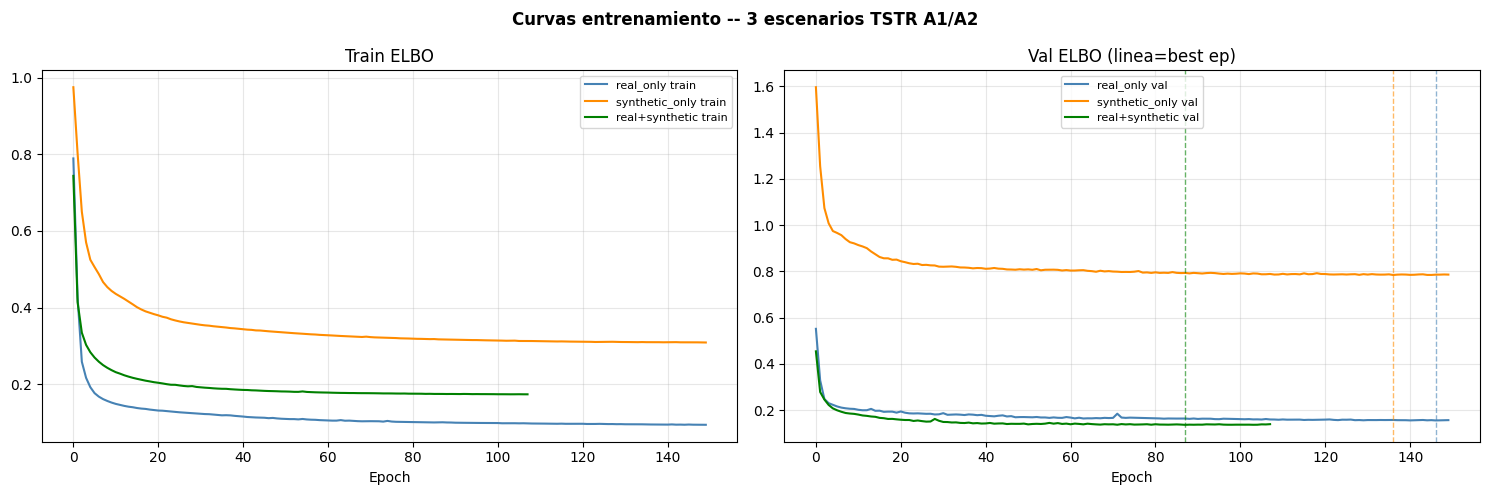

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for h_tr, h_va, ep, lbl, col in [
    (h_tr_r,  h_va_r,  ep_r, "real_only",      "steelblue"),
    (h_tr_s,  h_va_s,  ep_s, "synthetic_only", "darkorange"),
    (h_tr_c2, h_va_c2, ep_c, "real+synthetic", "green"),
]:
    axes[0].plot(h_tr, lw=1.5, color=col, label=f"{lbl} train")
    axes[1].plot(h_va, lw=1.5, color=col, label=f"{lbl} val")
    axes[1].axvline(ep-1, color=col, lw=1, linestyle="--", alpha=0.6)
for ax, ttl in zip(axes, ["Train ELBO", "Val ELBO (linea=best ep)"]):
    ax.set_title(ttl); ax.set_xlabel("Epoch")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle("Curvas entrenamiento -- 3 escenarios TSTR A1/A2", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(str(TSTR_DIR / "training_curves.png"), dpi=120, bbox_inches="tight")
plt.show()


## 13. Cargar modelos del disco y evaluar

Los modelos se recargan del disco para garantizar estado limpio.
La funcion `evaluate_model` recibe todos los datos como parametros
para evitar dependencias de variables globales de datos.

In [16]:
m_real_ev = build_model()
m_real_ev.load_state_dict(torch.load(TSTR_DIR / "model_real_only.pt", map_location=device))
m_real_ev.eval()

m_synth_ev = build_model()
m_synth_ev.load_state_dict(torch.load(TSTR_DIR / "model_synthetic_only.pt", map_location=device))
m_synth_ev.eval()

m_comb_ev = build_model()
m_comb_ev.load_state_dict(torch.load(TSTR_DIR / "model_real_plus_synthetic.pt", map_location=device))
m_comb_ev.eval()

print("Modelos recargados del disco OK")
print(f"Datos eval: X_eval_c={X_eval_c.shape} | y_all={len(y_all)} | df_wins={len(df_wins)}")
assert len(X_eval_c) == len(y_all) == len(df_wins)


Modelos recargados del disco OK
Datos eval: X_eval_c=(89972, 60, 25) | y_all=89972 | df_wins=89972


In [26]:
R_KEYS = ["real_only", "synthetic_only", "real_plus_synthetic"]
RES = {}

print(f"Evaluando (excl. IDs {EXCLUDED_IDS} | k={CONSEC_K} | sweep 800 taus)\n")
for mdl, lbl in [
    (m_real_ev,  "real_only"),
    (m_synth_ev, "synthetic_only"),
    (m_comb_ev,  "real_plus_synthetic"),
]:
    RES[lbl] = evaluate_model(mdl, X_eval_c, X_eval_d, y_all, df_wins, EXCLUDED_IDS, CONSEC_K)
    r = RES[lbl]
    print(f"  [{lbl}] AUC={r["roc_auc"]:.4f} | F1={r["f1"]:.3f} | "
          f"Rec={r["recall"]:.3f} | Prec={r["precision"]:.3f} | FPR={r["fpr"]:.3f}")


Evaluando (excl. IDs [] | k=13 | sweep 800 taus)

  [real_only] AUC=0.8165 | F1=0.748 | Rec=0.599 | Prec=0.995 | FPR=0.000
  [synthetic_only] AUC=0.8102 | F1=0.742 | Rec=0.592 | Prec=0.994 | FPR=0.000
  [real_plus_synthetic] AUC=0.8043 | F1=0.747 | Rec=0.602 | Prec=0.982 | FPR=0.002


## 14. Tabla comparativa

In [27]:
n_wins_map = {
    "real_only":           len(X_tr_c),
    "synthetic_only":      len(X_sy_c),
    "real_plus_synthetic": len(X_co_c),
}
df_comp = pd.DataFrame([{
    "Escenario"  : lbl,
    "Train_wins" : n_wins_map[lbl],
    "ROC-AUC"    : round(RES[lbl]["roc_auc"], 4),
    "PR-AUC"     : round(RES[lbl]["pr_auc"],  4),
    "F1"         : round(RES[lbl]["f1"],       3),
    "Recall"     : round(RES[lbl]["recall"],   3),
    "Precision"  : round(RES[lbl]["precision"],3),
    "FPR"        : round(RES[lbl]["fpr"],      3),
    "TP"         : RES[lbl]["tp"],
    "FP"         : RES[lbl]["fp"],
    "FN"         : RES[lbl]["fn"],
} for lbl in R_KEYS])
print(df_comp.to_string(index=False))
print()
base = RES["real_only"]
print("Delta vs real_only:")
for lbl in ["synthetic_only", "real_plus_synthetic"]:
    r = RES[lbl]
    print(f"  {lbl:<25}: DAUC={r["roc_auc"]-base["roc_auc"]:+.4f} | "
          f"DF1={r["f1"]-base["f1"]:+.3f} | DRec={r["recall"]-base["recall"]:+.3f} | "
          f"DFPR={r["fpr"]-base["fpr"]:+.3f}")
df_comp.to_csv(TSTR_DIR / "tabla_comparativa.csv", index=False)


          Escenario  Train_wins  ROC-AUC  PR-AUC    F1  Recall  Precision   FPR   TP  FP   FN
          real_only       59173   0.8165  0.7246 0.748   0.599      0.995 0.000 6784  36 4540
     synthetic_only       29587   0.8102  0.7127 0.742   0.592      0.994 0.000 6707  38 4617
real_plus_synthetic       88760   0.8043  0.7196 0.747   0.602      0.982 0.002 6820 126 4504

Delta vs real_only:
  synthetic_only           : DAUC=-0.0062 | DF1=-0.005 | DRec=-0.007 | DFPR=+0.000
  real_plus_synthetic      : DAUC=-0.0122 | DF1=-0.001 | DRec=+0.003 | DFPR=+0.001


## 15. Graficos comparativos

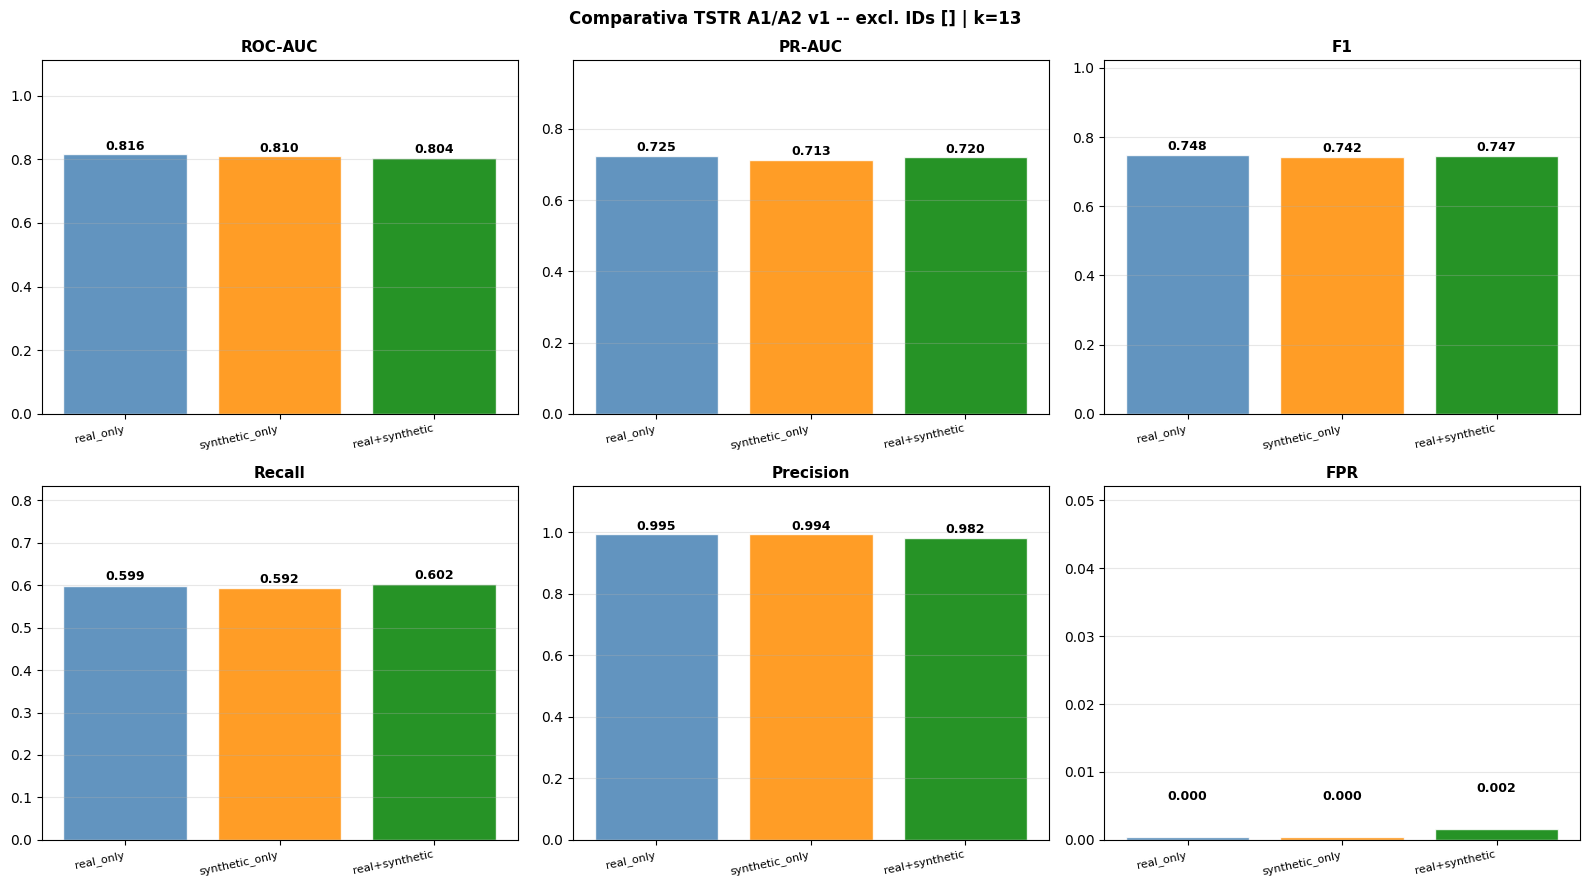

In [28]:
colors_sc = ["steelblue", "darkorange", "green"]
labels_sc  = ["real_only", "synthetic_only", "real+synthetic"]
met_keys   = ["roc_auc", "pr_auc", "f1", "recall", "precision", "fpr"]
met_labels = ["ROC-AUC", "PR-AUC", "F1", "Recall", "Precision", "FPR"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, mk, ml in zip(axes.flat, met_keys, met_labels):
    vals = [RES[lbl][mk] for lbl in R_KEYS]
    bars = ax.bar(labels_sc, vals, color=colors_sc, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(ml, fontsize=11, fontweight="bold")
    ax.set_ylim(0, min(1.15, max(vals)*1.3+0.05))
    ax.set_xticklabels(labels_sc, rotation=12, ha="right", fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")
plt.suptitle(f"Comparativa TSTR A1/A2 v1 -- excl. IDs {EXCLUDED_IDS} | k={CONSEC_K}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(str(TSTR_DIR / "metricas_comparativas.png"), dpi=130, bbox_inches="tight")
plt.show()


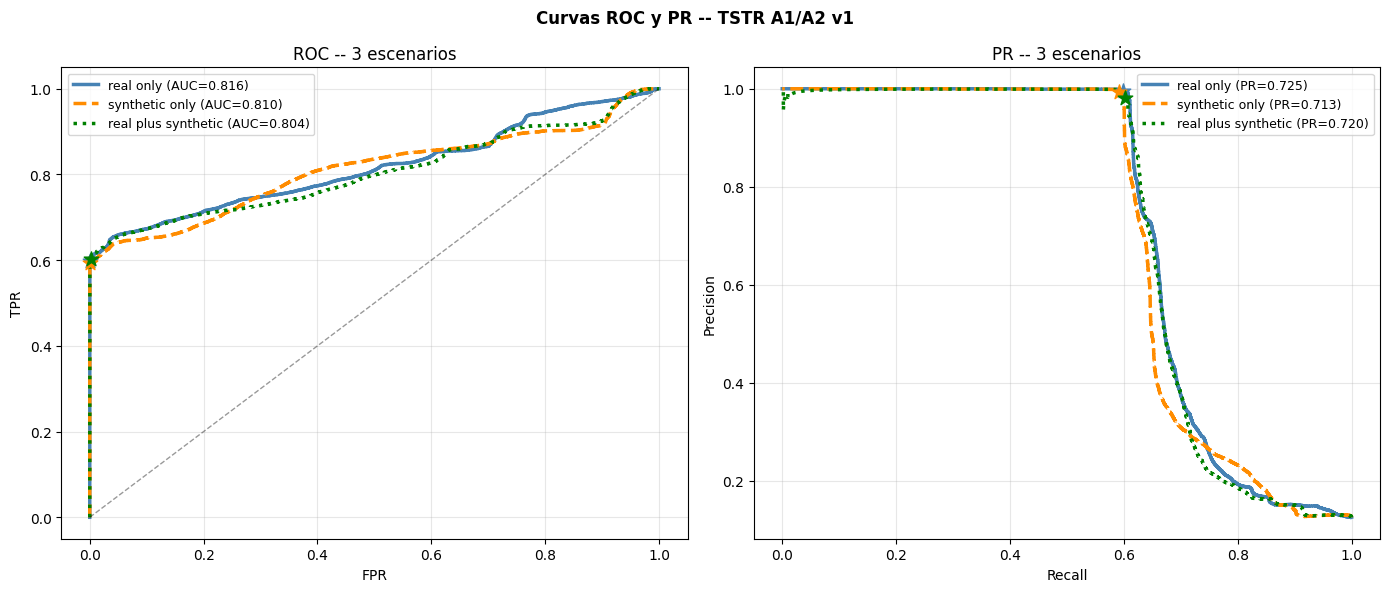

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for lbl, col, sty in zip(R_KEYS, colors_sc, ["-", "--", ":"]):
    r = RES[lbl]
    fp_, tp_, _ = roc_curve(r["y_filt"], r["sc_filt"])
    pr_, re_, _ = precision_recall_curve(r["y_filt"], r["sc_filt"])
    axes[0].plot(fp_, tp_, lw=2.5, color=col, linestyle=sty,
                 label=f'{lbl.replace("_"," ")} (AUC={r["roc_auc"]:.3f})')
    axes[0].scatter(r["fpr"], r["recall"], s=120, color=col, zorder=5, marker="*")
    axes[1].plot(re_, pr_, lw=2.5, color=col, linestyle=sty,
                 label=f'{lbl.replace("_"," ")} (PR={r["pr_auc"]:.3f})')
    axes[1].scatter(r["recall"], r["precision"], s=120, color=col, zorder=5, marker="*")
axes[0].plot([0,1],[0,1],"k--",lw=1,alpha=0.4)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC -- 3 escenarios"); axes[0].legend(fontsize=9); axes[0].grid(True,alpha=0.3)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR -- 3 escenarios"); axes[1].legend(fontsize=9); axes[1].grid(True,alpha=0.3)
plt.suptitle("Curvas ROC y PR -- TSTR A1/A2 v1", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(str(TSTR_DIR / "roc_pr_comparison.png"), dpi=130, bbox_inches="tight")
plt.show()


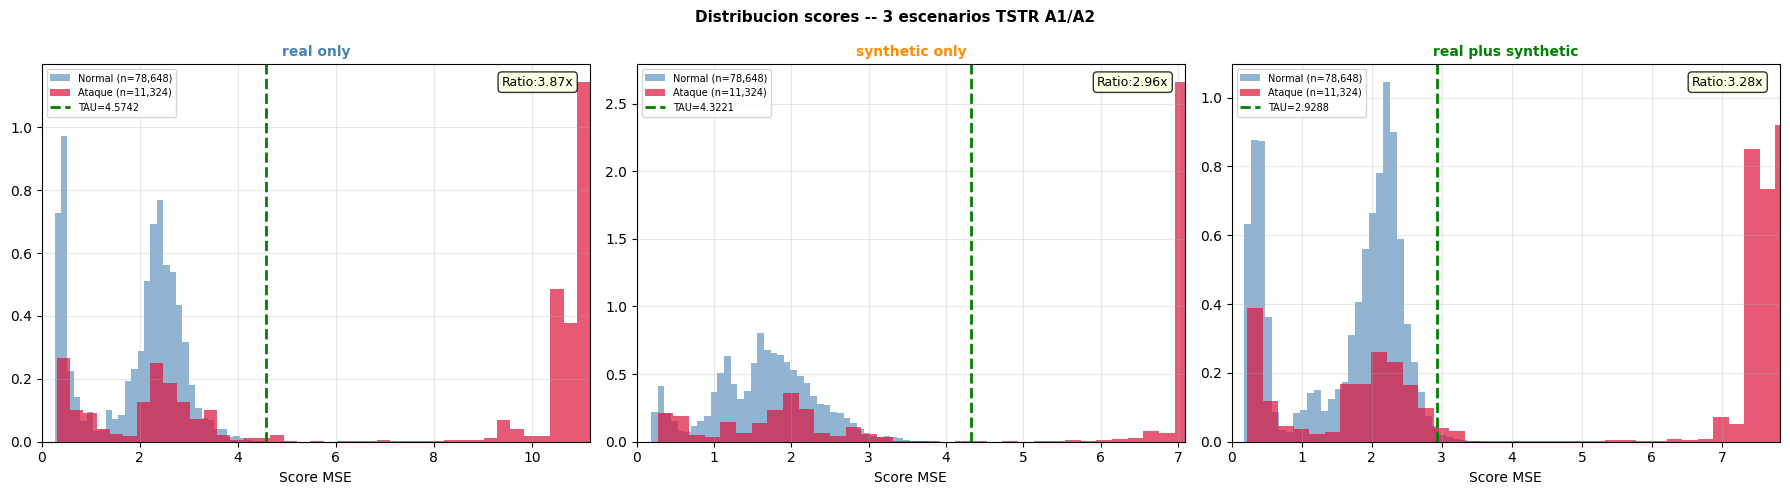

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, lbl, col in zip(axes, R_KEYS, colors_sc):
    sc = RES[lbl]["sc_all"]
    ax.hist(sc[y_all==0], bins=80, alpha=0.6, density=True, color="steelblue",
            label=f"Normal (n={(y_all==0).sum():,})")
    ax.hist(sc[y_all==1], bins=40, alpha=0.7, density=True, color="crimson",
            label=f"Ataque (n={(y_all==1).sum():,})")
    ax.axvline(RES[lbl]["tau"], color="green", lw=2, linestyle="--",
               label=f'TAU={RES[lbl]["tau"]:.4f}')
    ax.text(0.97, 0.97, f'Ratio:{RES[lbl]["ratio"]:.2f}x', ha="right", va="top",
            transform=ax.transAxes,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8), fontsize=9)
    ax.set_title(lbl.replace("_"," "), fontsize=10, fontweight="bold", color=col)
    ax.set_xlabel("Score MSE"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax.set_xlim(0, np.percentile(sc, 99.5))
plt.suptitle("Distribucion scores -- 3 escenarios TSTR A1/A2", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(str(TSTR_DIR / "score_distributions.png"), dpi=130, bbox_inches="tight")
plt.show()


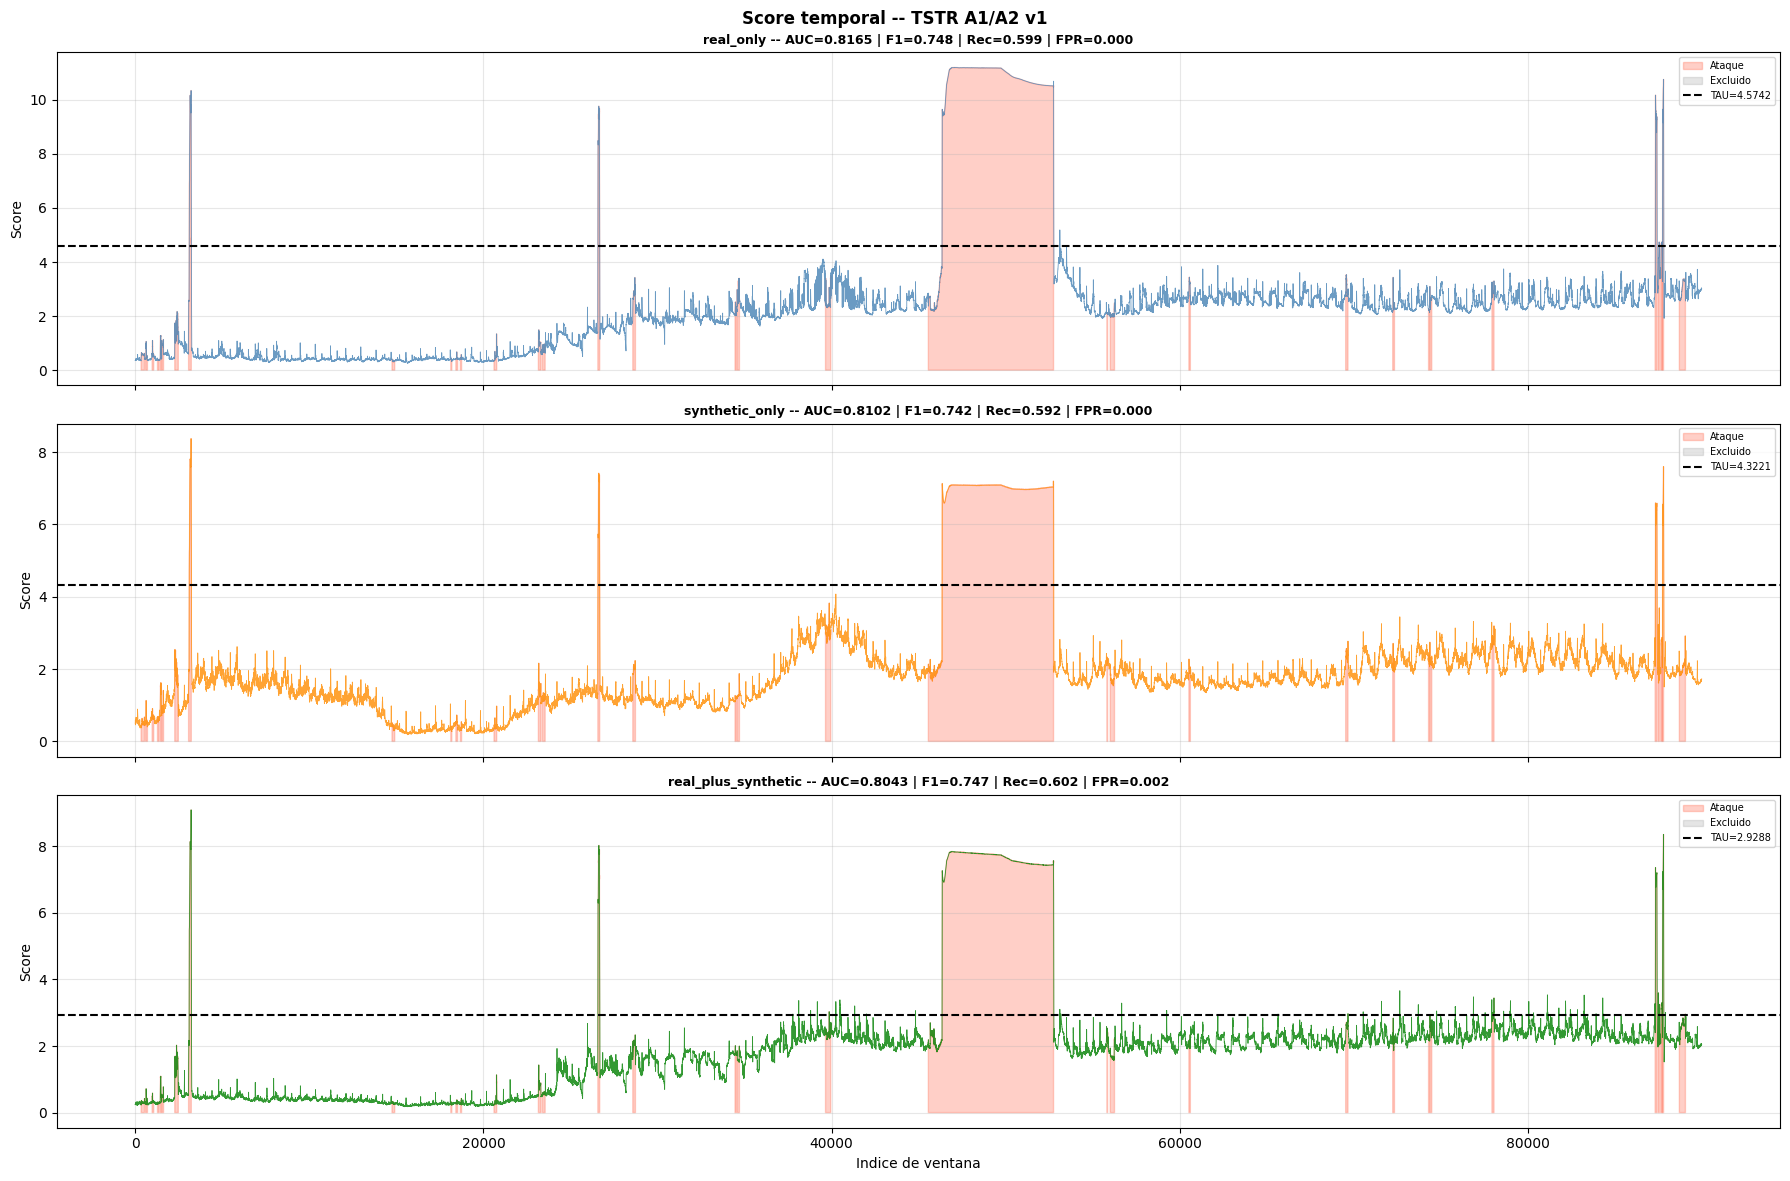

In [31]:
t_idx = np.arange(len(df_wins))
excl_mask = np.isin(df_wins["attack_id"].values, EXCLUDED_IDS) & (y_all==1)
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
for ax, lbl, col in zip(axes, R_KEYS, colors_sc):
    sc = RES[lbl]["sc_all"]
    ax.plot(t_idx, sc, color=col, lw=0.6, alpha=0.8)
    ax.fill_between(t_idx, 0, sc, where=(y_all==1)&~excl_mask,
                    color="tomato", alpha=0.30, label="Ataque")
    ax.fill_between(t_idx, 0, sc, where=excl_mask,
                    color="gray",  alpha=0.20, label="Excluido")
    ax.axhline(RES[lbl]["tau"], color="black", lw=1.5, linestyle="--",
               label=f'TAU={RES[lbl]["tau"]:.4f}')
    r = RES[lbl]
    ax.set_title(f'{lbl} -- AUC={r["roc_auc"]:.4f} | F1={r["f1"]:.3f} | '
                 f'Rec={r["recall"]:.3f} | FPR={r["fpr"]:.3f}',
                 fontsize=9, fontweight="bold")
    ax.set_ylabel("Score"); ax.legend(fontsize=7, loc="upper right"); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Indice de ventana")
plt.suptitle("Score temporal -- TSTR A1/A2 v1", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(str(TSTR_DIR / "score_temporal.png"), dpi=130, bbox_inches="tight")
plt.show()


 attack_id    nombre    n  det_real_only  det_synthetic_only  det_real_plus_synthetic  excluido
       1.0 Attack_01  200            0.0                 0.0                      0.0     False
       2.0 Attack_02  101            0.0                 0.0                      0.0     False
       3.0 Attack_03   88            0.0                 0.0                      0.0     False
       4.0 Attack_04   90            0.0                 0.0                      0.0     False
       5.0 Attack_05   51            0.0                 0.0                      0.0     False
       6.0 Attack_06   97            0.0                 0.0                      0.0     False
       7.0 Attack_07  204            0.0                 0.0                      0.0     False
       8.0 Attack_08  156           70.5                68.6                     72.4     False
       9.0 Attack_09  156            0.0                 0.0                      0.0     False
      10.0 Attack_10   58            0.0

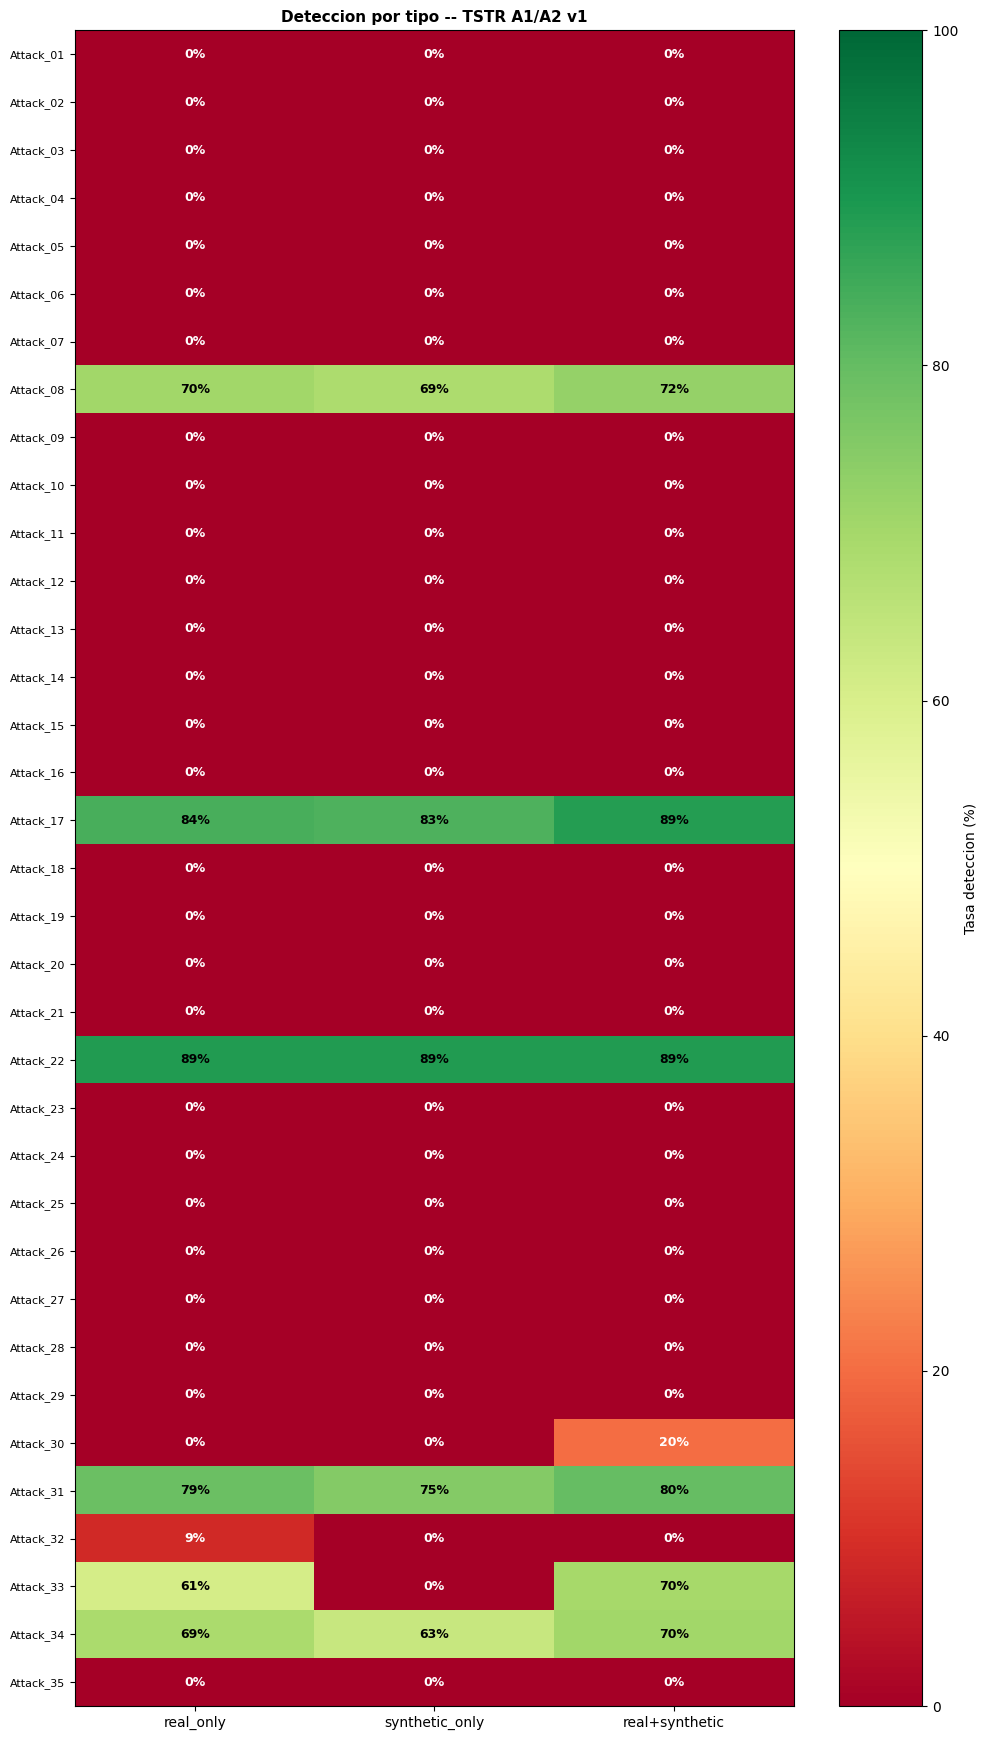

In [32]:
atk_ids_u = sorted(df_wins[df_wins["y"]==1]["attack_id"].unique())
det_rows = []
for aid in atk_ids_u:
    grp = df_wins[df_wins["attack_id"]==aid]
    n_t  = len(grp)
    nm   = grp["attack_name"].mode().iloc[0][:30]
    excl = bool(np.isin(aid, EXCLUDED_IDS))
    row  = {"attack_id": aid, "nombre": nm, "n": n_t, "excluido": excl}
    for lbl in R_KEYS:
        sc_g = RES[lbl]["sc_all"][df_wins["attack_id"]==aid]
        pg   = consec_filter(sc_g, RES[lbl]["tau"], CONSEC_K)
        row[f"det_{lbl}"] = round(100*pg.sum()/n_t, 1) if n_t>0 else 0.0
    det_rows.append(row)
df_det = pd.DataFrame(det_rows)
print(df_det[["attack_id","nombre","n","det_real_only",
              "det_synthetic_only","det_real_plus_synthetic","excluido"]].to_string(index=False))

df_heat = df_det[~df_det["excluido"]].set_index("nombre")
heat = df_heat[["det_real_only","det_synthetic_only","det_real_plus_synthetic"]].values
fig, ax = plt.subplots(figsize=(10, max(4, len(df_heat)*0.5)))
im = ax.imshow(heat, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
ax.set_xticks([0,1,2])
ax.set_xticklabels(["real_only","synthetic_only","real+synthetic"], fontsize=10)
ax.set_yticks(range(len(df_heat))); ax.set_yticklabels(df_heat.index.tolist(), fontsize=8)
for ii in range(len(df_heat)):
    for jj in range(3):
        ax.text(jj, ii, f"{heat[ii,jj]:.0f}%", ha="center", va="center",
                fontsize=9, fontweight="bold",
                color="white" if heat[ii,jj]<40 else "black")
plt.colorbar(im, ax=ax, label="Tasa deteccion (%)")
ax.set_title("Deteccion por tipo -- TSTR A1/A2 v1", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(str(TSTR_DIR / "deteccion_heatmap.png"), dpi=130, bbox_inches="tight")
plt.show()
df_det.to_csv(TSTR_DIR / "deteccion_por_tipo.csv", index=False)


## 16. Guardar resultados

Guardado en: c:\Users\j.manriquec\ics-synthetic-data-augmentation\models\detectors\lstm_vae_tstr_a1a2_v1

RESUMEN FINAL -- TSTR A1/A2 v1
  real_only                : AUC=0.8165 | F1=0.748 | Rec=0.599 | Prec=0.995 | FPR=0.000
  synthetic_only           : AUC=0.8102 | F1=0.742 | Rec=0.592 | Prec=0.994 | FPR=0.000
  real_plus_synthetic      : AUC=0.8043 | F1=0.747 | Rec=0.602 | Prec=0.982 | FPR=0.002

  Delta real+synth vs real_only: DAUC=-0.0122 | DF1=-0.001


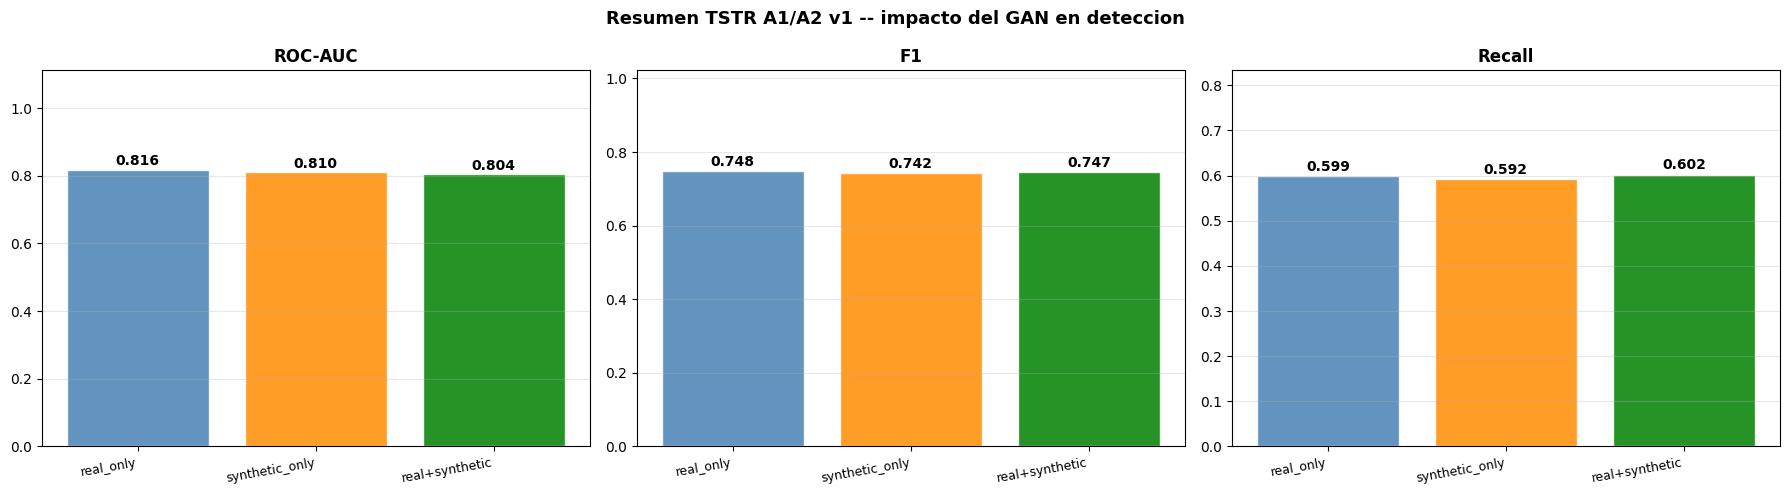

In [33]:
tstr_cfg = {
    "version":         "lstm_vae_tstr_a1a2_v1",
    "baseline":        "lstm_vae_swat_a1a2_baseline_v2",
    "timegan":         "lstm_vae_a1a2_baseline_v2",
    "normal_data":     str(NORMAL_XLSX),
    "attack_data":     str(ATTACK_XLSX),
    "eval_protocol":   {"excluded_ids": EXCLUDED_IDS, "k": CONSEC_K},
    "train_windows": {
        "real_only":           len(X_tr_c),
        "synthetic_only":      len(X_sy_c),
        "real_plus_synthetic": len(X_co_c),
    },
    "best_epochs": {
        "real_only": ep_r,
        "synthetic_only": ep_s,
        "real_plus_synthetic": ep_c,
    },
    "results": {
        lbl: {mk: RES[lbl][mk] for mk in
              ["tau","roc_auc","pr_auc","f1","recall","precision","fpr","tp","fp","fn","tn","ratio"]}
        for lbl in R_KEYS
    },
    "delta_vs_real_only": {
        lbl: {
            "delta_auc": round(RES[lbl]["roc_auc"]-RES["real_only"]["roc_auc"], 4),
            "delta_f1":  round(RES[lbl]["f1"]-RES["real_only"]["f1"],  3),
            "delta_rec": round(RES[lbl]["recall"]-RES["real_only"]["recall"], 3),
            "delta_fpr": round(RES[lbl]["fpr"]-RES["real_only"]["fpr"],  3),
        } for lbl in ["synthetic_only", "real_plus_synthetic"]
    },
}
with open(TSTR_DIR / "tstr_results.json", "w") as out_f:
    json.dump(tstr_cfg, out_f, indent=4)

print("Guardado en:", TSTR_DIR)
print()
print("="*70)
print("RESUMEN FINAL -- TSTR A1/A2 v1")
print("="*70)
for lbl in R_KEYS:
    r = RES[lbl]
    print(f"  {lbl:<25}: AUC={r["roc_auc"]:.4f} | F1={r["f1"]:.3f} | "
          f"Rec={r["recall"]:.3f} | Prec={r["precision"]:.3f} | FPR={r["fpr"]:.3f}")
print()
d = tstr_cfg["delta_vs_real_only"]["real_plus_synthetic"]
print(f"  Delta real+synth vs real_only: DAUC={d["delta_auc"]:+.4f} | DF1={d["delta_f1"]:+.3f}")
print("="*70)

# Guardar todos los plots en una grilla de resumen
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
met_summary = [("ROC-AUC","roc_auc"), ("F1","f1"), ("Recall","recall")]
for ax, (ml, mk) in zip(axes, met_summary):
    vals  = [RES[lbl][mk] for lbl in R_KEYS]
    bars  = ax.bar(labels_sc, vals, color=colors_sc, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(ml, fontsize=12, fontweight="bold")
    ax.set_ylim(0, min(1.15, max(vals)*1.3+0.05))
    ax.set_xticklabels(labels_sc, rotation=10, ha="right", fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")
plt.suptitle("Resumen TSTR A1/A2 v1 -- impacto del GAN en deteccion", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(str(TSTR_DIR / "resumen_tstr.png"), dpi=150, bbox_inches="tight")
plt.show()
